In [1]:
# Cài đặt các thư viện cần thiết
!pip install torch torchvision pandas nibabel SimpleITK scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-1

In [2]:
import os
import time
import random
import zipfile
import shutil
import gdown
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader



In [3]:
import torch
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import shutil

# Đọc file participants.xlsx
participants_file = "/kaggle/input/cam-can/data-20250425T101912Z-002/data/participants.xlsx"
participants_df = pd.read_excel(participants_file)

# Xóa sub-BrainAge019983 và sub-BrainAge005600 khỏi participants.xlsx
subjects_to_remove = ['sub-BrainAge019983', 'sub-BrainAge005600']
participants_df = participants_df[~participants_df['subject_id'].isin(subjects_to_remove)]
# Lưu participants.xlsx mới
filtered_participants_file = "/kaggle/working/participants_filtered.xlsx"
participants_df.to_excel(filtered_participants_file, index=False)
print(f"Đã xóa {len(subjects_to_remove)} subject khỏi participants.xlsx. File mới lưu tại: {filtered_participants_file}")

# Tạo dictionary ánh xạ subject_id
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }
print(f"Tổng số subject trong participants.xlsx (sau lọc): {len(subject_info)}")

# Thu thập danh sách file .nii
data_base_dir = "/kaggle/input/cam-can"
file_list = []
ages = []
genders = []
missing_subjects = []

for sub_dir in os.listdir(data_base_dir):
    sub_dir_path = os.path.join(data_base_dir, sub_dir, "data")
    if not os.path.exists(sub_dir_path):
        continue
    
    for root, dirs, files in os.walk(sub_dir_path):
        for file in files:
            if file.endswith('.nii'):
                file_path = os.path.join(root, file)
                parent_dir = os.path.basename(os.path.dirname(file_path))
                subject_id = parent_dir.split('_T1w')[0]
                if subject_id in subjects_to_remove:
                    continue  # Bỏ qua subject lỗi
                file_list.append(file_path)
                if subject_id in subject_info:
                    age = subject_info[subject_id]['age']
                    gender = subject_info[subject_id]['gender']
                    ages.append(age)
                    genders.append(gender)
                else:
                    missing_subjects.append((file_path, subject_id))

print(f"Tổng số file .nii tìm thấy: {len(file_list)}")
print(f"Số file không tìm thấy thông tin trong participants.xlsx: {len(missing_subjects)}")
if missing_subjects:
    print("Các subject không có thông tin:")
    for file_path, subject_id in missing_subjects[:5]:
        print(f" - {subject_id}: {file_path}")
    if len(missing_subjects) > 5:
        print(f" ... và {len(missing_subjects) - 5} subject khác.")
        
# Chuẩn hóa tuổi
max_age = 100
ages_normalized = np.array(ages) / max_age

Đã xóa 2 subject khỏi participants.xlsx. File mới lưu tại: /kaggle/working/participants_filtered.xlsx
Tổng số subject trong participants.xlsx (sau lọc): 4948
Tổng số file .nii tìm thấy: 4948
Số file không tìm thấy thông tin trong participants.xlsx: 0


Đã lưu tất cả dữ liệu vào: /kaggle/working/processed_mri_slices


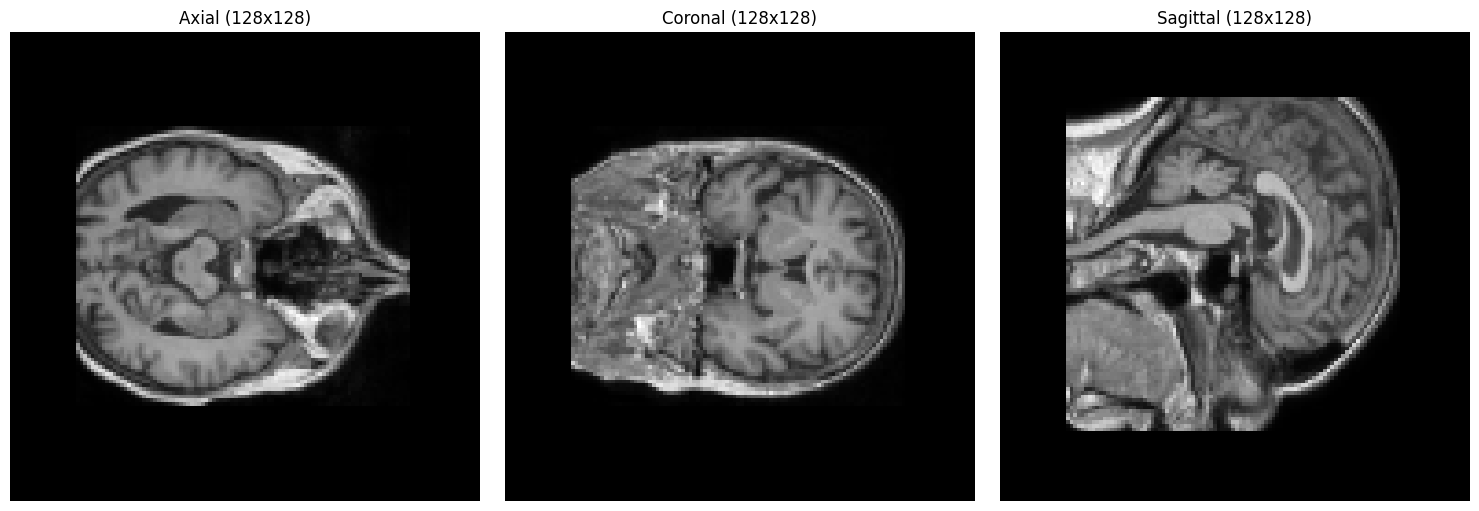

In [4]:
# Hàm tiền xử lý ảnh 2D
def preprocess_mri_slice(mri_slice):
    # Intensity normalization
    mri_normalized = (mri_slice - mri_slice.min()) / (mri_slice.max() - mri_slice.min() + 1e-8)
    return mri_normalized

# Xử lý và lưu 3 mặt cắt
output_base_dir = "/kaggle/working/processed_mri_slices"
os.makedirs(output_base_dir, exist_ok=True)
shutil.copy(filtered_participants_file, os.path.join(output_base_dir, "participants.xlsx"))

if not file_list:
    print("Không có file .nii hợp lệ để xử lý. Vui lòng kiểm tra dataset.")
else:
    for idx, file_path in enumerate(file_list):
        subject_id = os.path.basename(os.path.dirname(file_path)).split('_T1w')[0]
        subject_output_dir = os.path.join(output_base_dir, subject_id, "anat")
        os.makedirs(subject_output_dir, exist_ok=True)
        
        # Đọc ảnh 3D
        try:
            mri_img = nib.load(file_path)
            mri_data = mri_img.get_fdata()  # Shape: (130, 130, 130) hoặc tương tự
        except Exception as e:
            print(f"Lỗi khi đọc file {file_path}: {e}")
            continue
        
        # Lấy 3 mặt cắt giữa
        axial_idx = mri_data.shape[2] // 2
        coronal_idx = mri_data.shape[1] // 2
        sagittal_idx = mri_data.shape[0] // 2
        
        axial_slice = mri_data[:, :, axial_idx]  # Shape: (130, 130)
        coronal_slice = mri_data[:, coronal_idx, :]  # Shape: (130, 130)
        sagittal_slice = mri_data[sagittal_idx, :, :]  # Shape: (130, 130)
        
        # Cắt 1 pixel mỗi chiều
        axial_slice = axial_slice[1:-1, 1:-1]  # Shape: (128, 128)
        coronal_slice = coronal_slice[1:-1, 1:-1]
        sagittal_slice = sagittal_slice[1:-1, 1:-1]
        
        # Tiền xử lý
        axial_normalized = preprocess_mri_slice(axial_slice)
        coronal_normalized = preprocess_mri_slice(coronal_slice)
        sagittal_normalized = preprocess_mri_slice(sagittal_slice)
        
        # Chuẩn hóa về [-1, 1]
        axial_final = axial_normalized * 2 - 1
        coronal_final = coronal_normalized * 2 - 1
        sagittal_final = sagittal_normalized * 2 - 1
        
        # Lưu 3 mặt cắt
        for slice_type, slice_data in [
            ('axial', axial_final),
            ('coronal', coronal_final),
            ('sagittal', sagittal_final)
        ]:
            output_file = os.path.join(subject_output_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
            slice_data_3d = slice_data[np.newaxis, :, :]  # Shape: (1, 128, 128)
            try:
                nib.save(nib.Nifti1Image(slice_data_3d, np.eye(4)), output_file)
            except Exception as e:
                print(f"Lỗi khi lưu file {output_file}: {e}")
                continue
    print(f"Đã lưu tất cả dữ liệu vào: {output_base_dir}")

# Vẽ ví dụ 3 mặt cắt của subject đầu tiên
if file_list:
    sample_file = file_list[0]
    subject_id = os.path.basename(os.path.dirname(sample_file)).split('_T1w')[0]
    try:
        mri_img = nib.load(sample_file)
        mri_data = mri_img.get_fdata()
        axial_idx = mri_data.shape[2] // 2
        coronal_idx = mri_data.shape[1] // 2
        sagittal_idx = mri_data.shape[0] // 2
        axial_slice = mri_data[:, :, axial_idx][1:-1, 1:-1]  # Shape: (128, 128)
        coronal_slice = mri_data[:, coronal_idx, :][1:-1, 1:-1]
        sagittal_slice = mri_data[sagittal_idx, :, :][1:-1, 1:-1]
        axial_normalized = preprocess_mri_slice(axial_slice)
        coronal_normalized = preprocess_mri_slice(coronal_slice)
        sagittal_normalized = preprocess_mri_slice(sagittal_slice)
        axial_final = axial_normalized * 2 - 1
        coronal_final = coronal_normalized * 2 - 1
        sagittal_final = sagittal_normalized * 2 - 1

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.title("Axial (128x128)")
        plt.imshow(axial_final, cmap='gray')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.title("Coronal (128x128)")
        plt.imshow(coronal_final, cmap='gray')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.title("Sagittal (128x128)")
        plt.imshow(sagittal_final, cmap='gray')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig('/kaggle/working/sample_slices.png')
        plt.show()
        plt.close()
    except Exception as e:
        print(f"Lỗi khi xử lý file mẫu {sample_file}: {e}")
else:
    print("Không có file .nii hợp lệ để vẽ mẫu.")

In [8]:
# Nén thư mục processed_mri_slices thành file ZIP
if file_list:
    print("Đang nén dữ liệu đã xử lý thành file ZIP...")
    output_zip = "/kaggle/working/processed_mri_slices"
    if check_disk_space() > 1:  # Đảm bảo có ít nhất 1GB trống
        try:
            shutil.make_archive(output_zip, 'zip', output_base_dir)
            print(f"Đã nén dữ liệu vào: {output_zip}.zip")
        except Exception as e:
            print(f"Lỗi khi nén dữ liệu: {e}")
    else:
        print("Dung lượng ổ đĩa không đủ để nén dữ liệu.")
else:
    print("Không có dữ liệu để nén.")

Đang nén dữ liệu đã xử lý thành file ZIP...
Dung lượng trống: 18.65GB
Đã nén dữ liệu vào: /kaggle/working/processed_mri_slices.zip


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os
import nibabel as nib
import random
from collections import defaultdict
import time
import matplotlib.pyplot as plt
from torch.nn.utils import spectral_norm
from skimage.metrics import structural_similarity as ssim
import glob
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchvision.transforms import GaussianBlur

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Giải phóng VRAM
torch.cuda.empty_cache()

# Kiểm tra dung lượng ổ đĩa
def check_disk_space():
    stat = os.statvfs('/kaggle/working/')
    free_space = stat.f_bavail * stat.f_frsize / 1024**3
    print(f"Dung lượng trống: {free_space:.2f}GB")
    return free_space

check_disk_space()
if check_disk_space() < 1:
    print("Cảnh báo: Dung lượng ổ đĩa thấp, xóa file cũ...")
    for f in glob.glob("/kaggle/working/*.pth"):
        os.remove(f)
    for f in glob.glob("/kaggle/working/*.png"):
        os.remove(f)

# Kiểm tra ảnh gốc
def check_original_mri(data_dir, subjects):
    subject_id = subjects[0]
    subject_dir = os.path.join(data_dir, subject_id, "anat")
    file_path = os.path.join(subject_dir, f"{subject_id}_T1w_axial.nii.gz")
    mri_img = nib.load(file_path)
    mri_data = mri_img.get_fdata()[0]  # Shape: (128, 128)
    plt.figure()
    plt.imshow(mri_data, cmap='gray')
    plt.title(f"Original MRI Axial ({subject_id})")
    plt.axis('off')
    plt.savefig('/kaggle/working/original_slice.png')
    plt.close()
    print("Đã lưu ảnh gốc tại /kaggle/working/original_slice.png")

# Đọc participants.xlsx
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
participants_df = pd.read_excel(participants_file)
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Tạo chỉ mục cho truy vấn real_B
subjects = [s for s in os.listdir("/kaggle/working/processed_mri_slices") if s.startswith('sub-BrainAge')]
ages = [subject_info[s]['age'] for s in subjects]
genders = [subject_info[s]['gender'] for s in subjects]
min_age = 18
max_age = 97
ages_normalized = (np.array(ages) - min_age) / (max_age - min_age)  # Chuẩn hóa tuổi
condition_cache = defaultdict(list)
for idx, subject_id in enumerate(subjects):
    age = int(ages[idx])
    gender = genders[idx]
    condition_cache[(age, gender)].append(idx)

# Dataset với preload và kiểm tra nan/inf
class MRIDataset(Dataset):
    def __init__(self, data_dir, subjects, subject_info, target_shape=(128, 128)):
        self.data_dir = data_dir
        self.subjects = subjects
        self.subject_info = subject_info
        self.target_shape = target_shape
        self.data = []
        
        print("Preloading dataset...")
        for subject_id in subjects:
            subject_dir = os.path.join(data_dir, subject_id, "anat")
            slices = []
            for slice_type in ['axial', 'coronal', 'sagittal']:
                file_path = os.path.join(subject_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
                mri_img = nib.load(file_path)
                mri_data = mri_img.get_fdata()[0]  # Shape: (128, 128)
                if np.any(np.isnan(mri_data)) or np.any(np.isinf(mri_data)):
                    print(f"Cảnh báo: MRI {file_path} chứa nan/inf")
                    mri_data = np.nan_to_num(mri_data, nan=0.0, posinf=1.0, neginf=-1.0)
                mri_normalized = (mri_data - mri_data.min()) / (mri_data.max() - mri_data.min() + 1e-8)
                mri_normalized = mri_normalized * 2 - 1  # [-1, 1]
                slices.append(mri_normalized)
            mri_tensor = torch.tensor(np.stack(slices), dtype=torch.float32)
            if torch.any(torch.isnan(mri_tensor)) or torch.any(torch.isinf(mri_tensor)):
                print(f"Cảnh báo: MRI tensor chứa nan/inf cho subject {subject_id}")
            age = (subject_info[subject_id]['age'] - min_age) / (max_age - min_age)
            gender = subject_info[subject_id]['gender']
            condition = torch.tensor([age, gender], dtype=torch.float32)
            self.data.append((mri_tensor, condition))
        print("Dataset preloaded.")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

# Hàm truy vấn ảnh
def get_image_and_condition(idx, dataset):
    mri_tensor, condition = dataset[idx]
    return mri_tensor.to(device), condition.to(device)

# Tạo Dataset và DataLoader
data_dir = "/kaggle/working/processed_mri_slices"
dataset = MRIDataset(data_dir, subjects, subject_info, target_shape=(128, 128))
check_original_mri(data_dir, subjects)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)

Thiết bị đang sử dụng: cuda
Dung lượng trống: 17.86GB
Dung lượng trống: 17.86GB
Preloading dataset...
Dataset preloaded.
Đã lưu ảnh gốc tại /kaggle/working/original_slice.png


In [13]:
# FiLM Layer
class FiLM(nn.Module):
    def __init__(self, condition_dim, num_features):
        super().__init__()
        self.gamma = nn.Linear(condition_dim, num_features)
        self.beta = nn.Linear(condition_dim, num_features)
    
    def forward(self, x, condition):
        gamma = self.gamma(condition).view(x.size(0), x.size(1), 1, 1)
        beta = self.beta(condition).view(x.size(0), x.size(1), 1, 1)
        return gamma * x + beta

# Residual Block
class ResBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
        )
    
    def forward(self, x):
        return x + self.conv_block(x)

# Self-Attention Layer
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query_conv = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.key_conv = nn.Conv2d(in_dim, in_dim // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_dim, in_dim, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, x):
        batch_size, C, width, height = x.size()
        query = self.query_conv(x).view(batch_size, -1, width * height).permute(0, 2, 1)
        key = self.key_conv(x).view(batch_size, -1, width * height)
        energy = torch.bmm(query, key)
        attention = self.softmax(energy)
        value = self.value_conv(x).view(batch_size, -1, width * height)
        out = torch.bmm(value, attention.permute(0, 2, 1))
        out = out.view(batch_size, C, width, height)
        out = self.gamma * out + x
        return out

# U-Net Generator với Upsample + Conv2d
class Generator(nn.Module):
    def __init__(self, condition_dim=4, use_self_attention=False):
        super().__init__()
        self.condition_dim = condition_dim
        self.use_self_attention = use_self_attention
        
        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
        )
        self.film1 = FiLM(condition_dim, 64)
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.film2 = FiLM(condition_dim, 128)
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
        )
        self.film3 = FiLM(condition_dim, 256)
        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )
        self.film4 = FiLM(condition_dim, 512)
        
        # Middle
        self.middle = nn.Sequential(
            ResBlock(512),
            SelfAttention(512) if use_self_attention else nn.Identity(),
            ResBlock(512),
        )
        
        # Decoder
        self.dec4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.dec3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(512, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.dec2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.dec1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )
    
    def forward(self, x, condition):
        e1 = self.enc1(x)
        e1 = self.film1(e1, condition)
        e2 = self.enc2(e1)
        e2 = self.film2(e2, condition)
        e3 = self.enc3(e2)
        e3 = self.film3(e3, condition)
        e4 = self.enc4(e3)
        e4 = self.film4(e4, condition)
        m = self.middle(e4)
        d4 = self.dec4(m)
        d3 = self.dec3(torch.cat([d4, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        out = self.dec1(torch.cat([d2, e1], dim=1))
        return out

# Discriminator với Auxiliary Classifier, thêm sigmoid cho age_head
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1)),
            nn.LeakyReLU(0.2),
            spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            spectral_norm(nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            spectral_norm(nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        self.real_fake_head = nn.Linear(512 * 8 * 8, 1)
        self.age_head = nn.Sequential(
            nn.Linear(512 * 8 * 8, 1),
            nn.Sigmoid()  # Giới hạn đầu ra [0, 1]
        )
        self.gender_head = nn.Linear(512 * 8 * 8, 1)
    
    def forward(self, x, return_features=False):
        features = self.model(x)
        real_fake = self.real_fake_head(features)
        age = self.age_head(features)
        gender = self.gender_head(features)
        if return_features:
            return real_fake, age, gender, features
        return real_fake, age, gender
    
    def feature_maps(self, x):
        features = []
        x = x
        for layer in self.model[:-1]:
            x = layer(x)
            features.append(x)
        return features


In [16]:
# Khởi tạo mô hình
use_self_attention = False
G_A_to_B = Generator(use_self_attention=use_self_attention).to(device)
G_B_to_A = Generator(use_self_attention=use_self_attention).to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

# Loss functions và optimizers
adversarial_loss = nn.BCEWithLogitsLoss()
cycle_loss_fn = nn.L1Loss()
l2_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()
ssim_loss = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)
optimizer_G = optim.Adam(list(G_A_to_B.parameters()) + list(G_B_to_A.parameters()), lr=0.0001, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=0.00005, betas=(0.5, 0.999))  # Giảm lr cho D_B
scheduler_G = optim.lr_scheduler.ReduceLROnPlateau(optimizer_G, mode='min', factor=0.5, patience=10)
scheduler_D_A = optim.lr_scheduler.ReduceLROnPlateau(optimizer_D_A, mode='min', factor=0.5, patience=10)
scheduler_D_B = optim.lr_scheduler.ReduceLROnPlateau(optimizer_D_B, mode='min', factor=0.5, patience=10)

# Mixed precision
scaler = torch.amp.GradScaler('cuda')

# Gaussian blur để giảm nhiễu
blur = GaussianBlur(kernel_size=3, sigma=1.0).to(device)

# Lưu ảnh so sánh
def save_comparison_images(epoch, real_A, real_B, condition_A_to_B, G_A_to_B):
    if check_disk_space() < 1:
        print("Dung lượng thấp, không lưu ảnh so sánh.")
        return
    with torch.no_grad():
        fake_B = G_A_to_B(real_A[:1], condition_A_to_B[:1])
        fake_B = blur(fake_B)  # Áp dụng blur
        fake_B = fake_B.cpu().numpy()[0]
        real_B_sample = real_B[:1].cpu().numpy()[0]
        ssim_vals = [ssim(fake_B[j], real_B_sample[j], data_range=2) for j in range(3)]
        
        plt.figure(figsize=(15, 10))
        for j, title in enumerate(["Axial", "Coronal", "Sagittal"]):
            plt.subplot(2, 3, j+1)
            plt.title(f"Fake {title} (Epoch {epoch+1})")
            plt.imshow(fake_B[j], cmap='gray')
            plt.axis('off')
            plt.subplot(2, 3, j+4)
            plt.title(f"Real {title}")
            plt.imshow(real_B_sample[j], cmap='gray')
            plt.axis('off')
        plt.savefig(f"/kaggle/working/compare_slices_epoch_{epoch+1}.png")
        plt.close()
        print(f"Đã lưu ảnh so sánh tại /kaggle/working/compare_slices_epoch_{epoch+1}.png")
        return ssim_vals

# Huấn luyện
epochs = 200
min_age = 18
max_age = 97
accum_steps = 1

for epoch in range(epochs):
    d_a_losses = []
    d_b_losses = []
    g_losses = []
    d_a_age_losses = []
    d_a_gender_losses = []
    d_b_age_losses = []
    d_b_gender_losses = []
    g_age_losses = []
    g_gender_losses = []
    ssim_scores = {'axial': [], 'coronal': [], 'sagittal': []}
    num_batches = 0
    data_time = 0
    model_time = 0
    query_time = 0
    
    optimizer_G.zero_grad()
    optimizer_D_A.zero_grad()
    optimizer_D_B.zero_grad()
    
    for i, (real_A, condition_A) in enumerate(dataloader):
        start_time = time.time()
        real_A = real_A.to(device)
        condition_A = condition_A.to(device)
        batch_size = real_A.size(0)
        data_time += time.time() - start_time
        
        target_age = torch.randint(int(min_age), int(max_age) + 1, (batch_size,), device=device).float()
        target_age_normalized = (target_age - min_age) / (max_age - min_age)
        target_gender = torch.randint(0, 2, (batch_size,), device=device).float()
        condition_A_to_B = torch.stack([condition_A[:, 0], condition_A[:, 1], target_age_normalized, target_gender], dim=1)
        
        query_start = time.time()
        idx_B_list = []
        for j in range(batch_size):
            target_age_i = int(target_age[j].item())
            target_gender_i = int(target_gender[j].item())
            candidates = []
            for age_diff in range(11):
                for age in [target_age_i - age_diff, target_age_i + age_diff]:
                    candidates.extend(condition_cache.get((age, target_gender_i), []))
            if not candidates:
                age_diffs = [
                    (abs(ages[idx] - target_age_i) + (genders[idx] != target_gender_i) * 1000, idx)
                    for idx in range(len(subjects))
                ]
                age_diffs.sort()
                candidates = [age_diffs[0][1]]
            idx_B = random.choice(candidates)
            idx_B_list.append(idx_B)
        
        real_B_list = []
        condition_B_list = []
        for idx_B in idx_B_list:
            real_B_i, condition_B_i = get_image_and_condition(idx_B, dataset)
            real_B_list.append(real_B_i.unsqueeze(0))
            condition_B_list.append(condition_B_i)
        real_B = torch.cat(real_B_list, dim=0)
        condition_B = torch.stack([target_age_normalized, target_gender], dim=1)
        condition_B_to_A = torch.cat([condition_B[:, :2], condition_A[:, :2]], dim=1)
        query_time += time.time() - query_start
        
        # Kiểm tra điều kiện real_B
        if i==1:
            print(f"Batch {i}, Target age: {target_age[0].item()}, Selected age: {ages[idx_B_list[0]]}, "
              f"Target gender: {target_gender[0].item()}, Selected gender: {genders[idx_B_list[0]]}")
        
        model_start = time.time()
        with torch.amp.autocast('cuda'):
            # Discriminator A
            real_A_rf, real_A_age, real_A_gender = D_A(real_A)
            fake_A = G_B_to_A(real_B, condition_B_to_A)
            fake_A = blur(fake_A)  # Áp dụng blur
            fake_A_rf, fake_A_age, fake_A_gender = D_A(fake_A.detach())
            d_A_loss_rf = (adversarial_loss(real_A_rf, torch.ones_like(real_A_rf)) +
                           adversarial_loss(fake_A_rf, torch.zeros_like(fake_A_rf))) * 0.5
            d_A_loss_age = l2_loss(real_A_age.squeeze(), condition_A[:, 0])  # Tuổi chuẩn hóa [0, 1]
            d_A_loss_gender = bce_loss(real_A_gender.squeeze(), condition_A[:, 1])
            d_A_loss = d_A_loss_rf + 0.1 * d_A_loss_age + 0.5 * d_A_loss_gender
            
            # Discriminator B
            real_B_rf, real_B_age, real_B_gender = D_B(real_B)
            fake_B = G_A_to_B(real_A, condition_A_to_B)
            fake_B = blur(fake_B)  # Áp dụng blur
            fake_B_rf, fake_B_age, fake_B_gender = D_B(fake_B.detach())
            d_B_loss_rf = (adversarial_loss(real_B_rf, torch.ones_like(real_B_rf)) +
                           adversarial_loss(fake_B_rf, torch.zeros_like(fake_B_rf))) * 0.5
            d_B_loss_age = l2_loss(real_B_age.squeeze(), target_age_normalized)  # Tuổi chuẩn hóa [0, 1]
            d_B_loss_gender = bce_loss(real_B_gender.squeeze(), target_gender)
            d_B_loss = d_B_loss_rf + 0.1 * d_B_loss_age + 0.5 * d_B_loss_gender
        
        scaler.scale(d_A_loss / accum_steps).backward()
        scaler.scale(d_B_loss / accum_steps).backward()
        
        # Generator
        fake_B = G_A_to_B(real_A, condition_A_to_B)
        fake_B = blur(fake_B)
        fake_A = G_B_to_A(real_B, condition_B_to_A)
        fake_A = blur(fake_A)
        fake_B_rf, fake_B_age, fake_B_gender = D_B(fake_B)
        fake_A_rf, fake_A_age, fake_A_gender = D_A(fake_A)
        cycled_A = G_B_to_A(fake_B, condition_B_to_A)
        cycled_A = blur(cycled_A)
        cycled_B = G_A_to_B(fake_A, condition_A_to_B)
        cycled_B = blur(cycled_B)
        
        with torch.amp.autocast('cuda'):
            g_A_to_B_loss = adversarial_loss(fake_B_rf, torch.ones_like(fake_B_rf))
            g_B_to_A_loss = adversarial_loss(fake_A_rf, torch.ones_like(fake_A_rf))
            cycle_A_loss = cycle_loss_fn(real_A, cycled_A)
            cycle_B_loss = cycle_loss_fn(real_B, cycled_B)
            l2_A_loss = l2_loss(fake_A, real_A)
            l2_B_loss = l2_loss(fake_B, real_B)
            ssim_A_loss = 1 - ssim_loss(fake_A, real_A)
            ssim_B_loss = 1 - ssim_loss(fake_B, real_B)
            real_A_features = D_A.feature_maps(real_A)
            fake_A_features = D_A.feature_maps(fake_A)
            real_B_features = D_B.feature_maps(real_B)
            fake_B_features = D_B.feature_maps(fake_B)
            fm_A_loss = sum(l2_loss(f, r) for f, r in zip(fake_A_features, real_A_features)) / len(real_A_features)
            fm_B_loss = sum(l2_loss(f, r) for f, r in zip(fake_B_features, real_B_features)) / len(real_B_features)
            
            g_B_age_loss = l2_loss(fake_B_age.squeeze(), target_age_normalized)
            g_B_gender_loss = bce_loss(fake_B_gender.squeeze(), target_gender)
            g_A_age_loss = l2_loss(fake_A_age.squeeze(), condition_A[:, 0])
            g_A_gender_loss = bce_loss(fake_A_gender.squeeze(), condition_A[:, 1])
            
            total_g_loss = (
                g_A_to_B_loss + g_B_to_A_loss +
                10.0 * (cycle_A_loss + cycle_B_loss) +
                1.0 * (l2_A_loss + l2_B_loss) +
                2.0 * (ssim_A_loss + ssim_B_loss) +
                5.0 * (fm_A_loss + fm_B_loss) +
                1.0 * (g_B_age_loss + g_B_gender_loss + 2.0 * g_A_age_loss + 2.0 * g_A_gender_loss)
            )
        
        scaler.scale(total_g_loss / accum_steps).backward()
        
        if (i + 1) % accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(list(G_A_to_B.parameters()) + list(G_B_to_A.parameters()), max_norm=0.5)
            torch.nn.utils.clip_grad_norm_(D_A.parameters(), max_norm=0.5)
            torch.nn.utils.clip_grad_norm_(D_B.parameters(), max_norm=0.5)
            scaler.step(optimizer_G)
            scaler.step(optimizer_D_A)
            scaler.step(optimizer_D_B)
            scaler.update()
            optimizer_G.zero_grad()
            optimizer_D_A.zero_grad()
            optimizer_D_B.zero_grad()
        
        model_time += time.time() - model_start
        
        d_a_losses.append(d_A_loss.item())
        d_b_losses.append(d_B_loss.item())
        g_losses.append(total_g_loss.item())
        d_a_age_losses.append(d_A_loss_age.item())
        d_a_gender_losses.append(d_A_loss_gender.item())
        d_b_age_losses.append(d_B_loss_age.item())
        d_b_gender_losses.append(d_B_loss_gender.item())
        g_age_losses.append((g_B_age_loss.item() + g_A_age_loss.item()) / 2)
        g_gender_losses.append((g_B_gender_loss.item() + g_A_gender_loss.item()) / 2)
        num_batches += 1
        
        # Lưu ảnh so sánh ở epoch 1 và mỗi 5 epoch
        if i == 0 and (epoch == 0 or (epoch + 1) % 5 == 0):
            ssim_vals = save_comparison_images(epoch, real_A, real_B, condition_A_to_B, G_A_to_B)
            ssim_scores['axial'].append(ssim_vals[0])
            ssim_scores['coronal'].append(ssim_vals[1])
            ssim_scores['sagittal'].append(ssim_vals[2])
        
        if i % 50 == 0:
            print(f"Batch {i}, Data time: {data_time:.2f}s, Query time: {query_time:.2f}s, Model time: {model_time:.2f}s, "
                  f"VRAM: {torch.cuda.memory_allocated() / 1024**2:.2f}MB")
    
    avg_d_a_loss = sum(d_a_losses) / num_batches
    avg_d_b_loss = sum(d_b_losses) / num_batches
    avg_g_loss = sum(g_losses) / num_batches
    avg_d_a_age_loss = sum(d_a_age_losses) / num_batches
    avg_d_a_gender_loss = sum(d_a_gender_losses) / num_batches
    avg_d_b_age_loss = sum(d_b_age_losses) / num_batches
    avg_d_b_gender_loss = sum(d_b_gender_losses) / num_batches
    avg_g_age_loss = sum(g_age_losses) / num_batches
    avg_g_gender_loss = sum(g_gender_losses) / num_batches
    avg_ssim_axial = np.mean(ssim_scores['axial']) if ssim_scores['axial'] else 0
    avg_ssim_coronal = np.mean(ssim_scores['coronal']) if ssim_scores['coronal'] else 0
    avg_ssim_sagittal = np.mean(ssim_scores['sagittal']) if ssim_scores['sagittal'] else 0
    print(f"Epoch {epoch+1}, Avg D_A Loss: {avg_d_a_loss:.4f}, Avg D_B Loss: {avg_d_b_loss:.4f}, Avg G Loss: {avg_g_loss:.4f}, "
          f"D_A Age Loss: {avg_d_a_age_loss:.4f}, D_A Gender Loss: {avg_d_a_gender_loss:.4f}, "
          f"D_B Age Loss: {avg_d_b_age_loss:.4f}, D_B Gender Loss: {avg_d_b_gender_loss:.4f}, "
          f"G Age Loss: {avg_g_age_loss:.4f}, G Gender Loss: {avg_g_gender_loss:.4f}, "
          f"Avg SSIM Axial: {avg_ssim_axial:.4f}, Coronal: {avg_ssim_coronal:.4f}, Sagittal: {avg_ssim_sagittal:.4f}")
    
    scheduler_G.step(avg_g_loss)
    scheduler_D_A.step(avg_d_a_loss)
    scheduler_D_B.step(avg_d_b_loss)
    
    if (epoch + 1) % 5 == 0 and check_disk_space() > 1:
        try:
            torch.save(G_A_to_B.state_dict(), f"/kaggle/working/G_A_to_B_epoch_{epoch+1}.pth")
            torch.save(G_B_to_A.state_dict(), f"/kaggle/working/G_B_to_A_epoch_{epoch+1}.pth")
            print(f"Đã lưu mô hình tại epoch {epoch+1}")
        except RuntimeError as e:
            print(f"Lỗi khi lưu mô hình: {e}")


Dung lượng trống: 17.86GB
Đã lưu ảnh so sánh tại /kaggle/working/compare_slices_epoch_1.png
Batch 0, Data time: 0.00s, Query time: 0.01s, Model time: 0.74s, VRAM: 1936.38MB
Batch 1, Target age: 57.0, Selected age: 55.088295687885, Target gender: 1.0, Selected gender: 1
Batch 50, Data time: 0.03s, Query time: 0.26s, Model time: 36.85s, VRAM: 1934.83MB
Batch 100, Data time: 0.06s, Query time: 0.51s, Model time: 72.98s, VRAM: 1933.73MB
Batch 150, Data time: 0.09s, Query time: 0.76s, Model time: 109.11s, VRAM: 1935.10MB
Epoch 1, Avg D_A Loss: 0.9411, Avg D_B Loss: 0.9125, Avg G Loss: 8.2927, D_A Age Loss: 0.0562, D_A Gender Loss: 0.5107, D_B Age Loss: 0.0608, D_B Gender Loss: 0.4639, G Age Loss: 0.0273, G Gender Loss: 0.0639, Avg SSIM Axial: -0.1962, Coronal: 0.2779, Sagittal: 0.1294
Batch 0, Data time: 0.00s, Query time: 0.00s, Model time: 0.72s, VRAM: 1941.33MB
Batch 1, Target age: 46.0, Selected age: 47.0, Target gender: 0.0, Selected gender: 0
Batch 50, Data time: 0.03s, Query time: 0.

KeyboardInterrupt: 

Thiết bị đang sử dụng: cuda
Tổng số subject: 4948
Tải mô hình từ: /kaggle/working/G_A_to_B_epoch_135.pth

Subject: sub-BrainAge005759
Tuổi gốc: 20.0, Giới tính gốc: Nam


/tmp/ipykernel_31/2047550778.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  G_A_to_B.load_state_dict(torch.load(model_path))


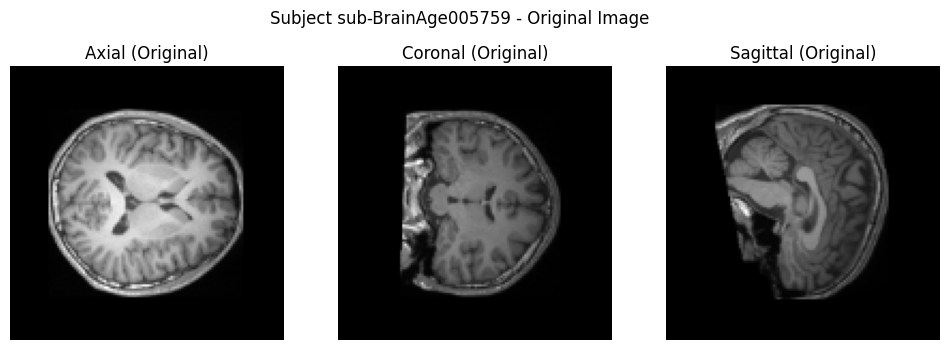

Target: Tuổi đích 25, Giới tính đích Nam


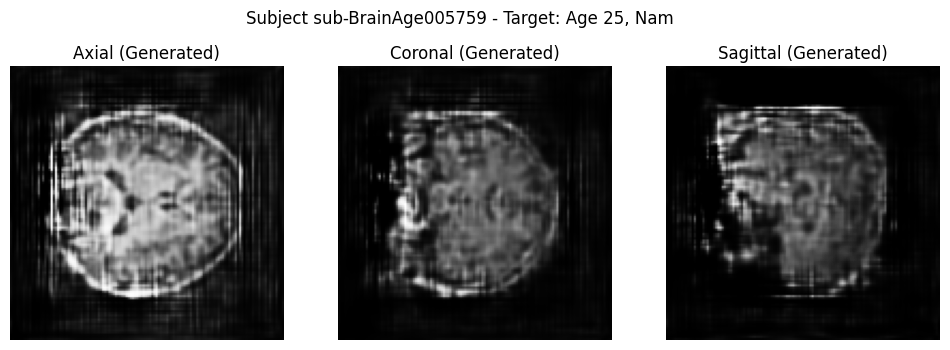

Target: Tuổi đích 25, Giới tính đích Nữ


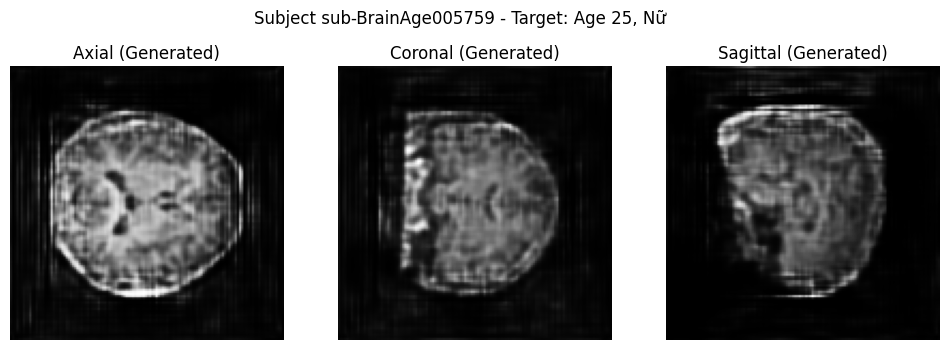

Target: Tuổi đích 50, Giới tính đích Nam


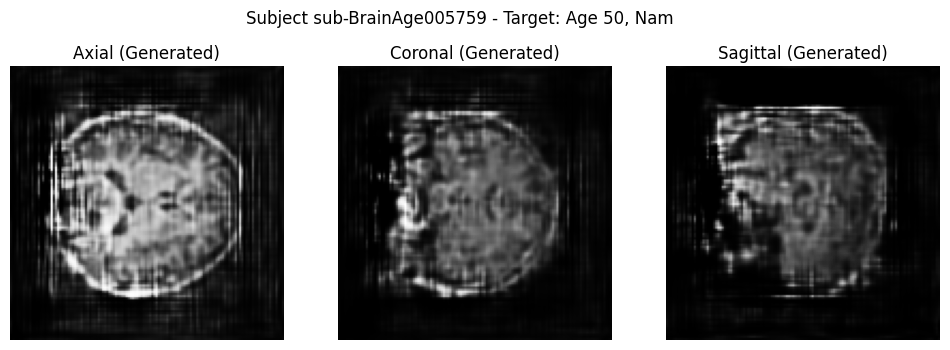

Target: Tuổi đích 50, Giới tính đích Nữ


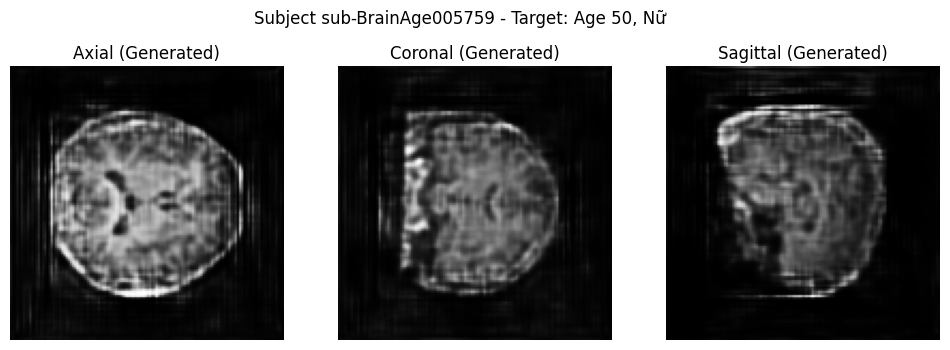


Subject: sub-BrainAge022446
Tuổi gốc: 78.0, Giới tính gốc: Nữ


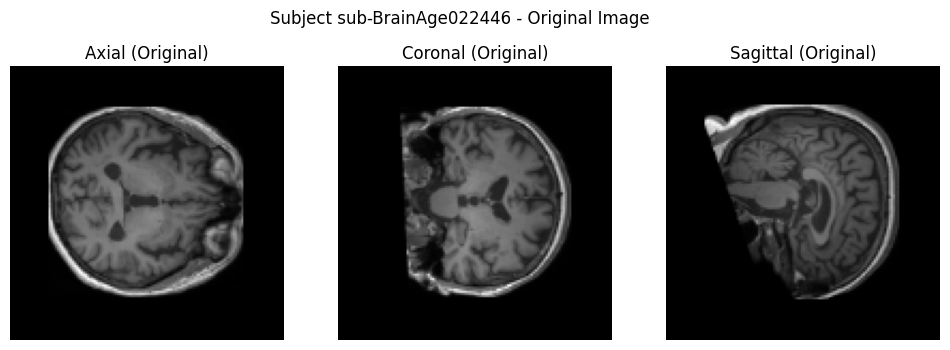

Target: Tuổi đích 25, Giới tính đích Nam


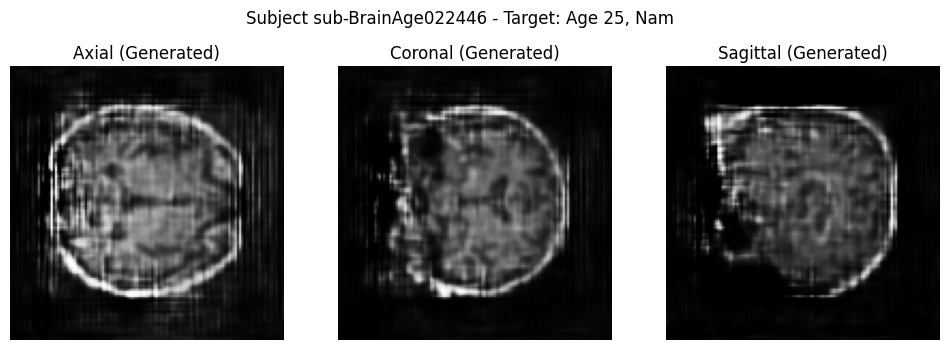

Target: Tuổi đích 25, Giới tính đích Nữ


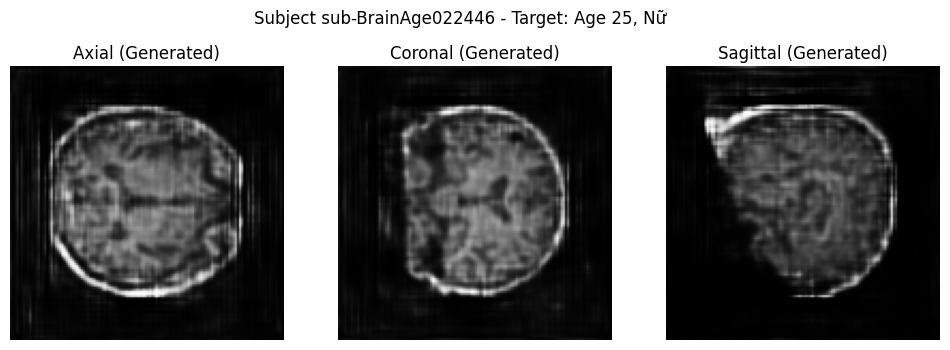

Target: Tuổi đích 50, Giới tính đích Nam


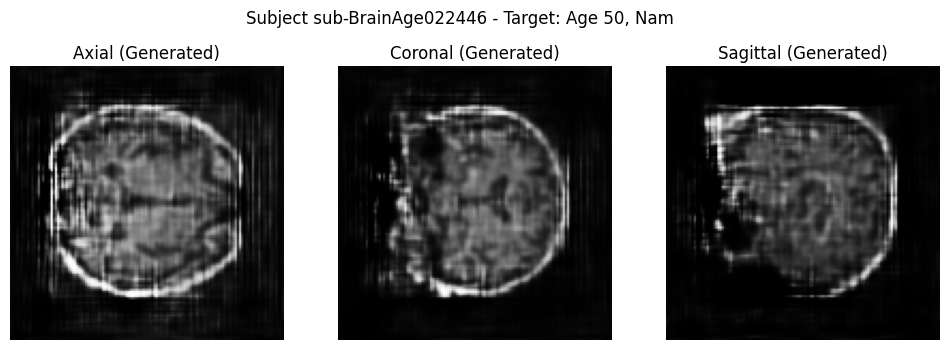

Target: Tuổi đích 50, Giới tính đích Nữ


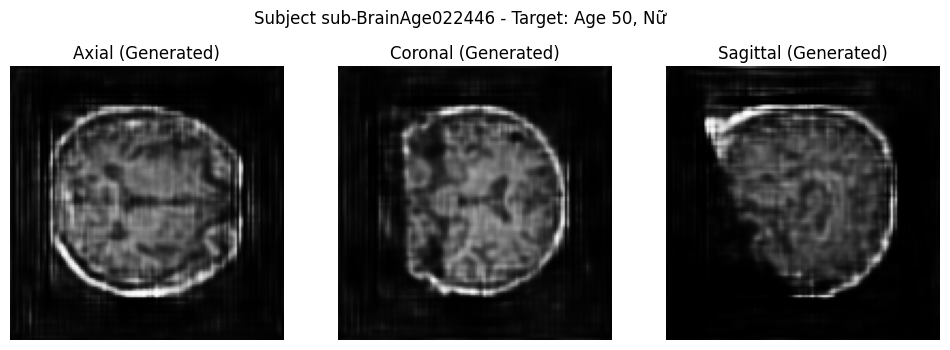


Subject: sub-BrainAge021339
Tuổi gốc: 83.0, Giới tính gốc: Nữ


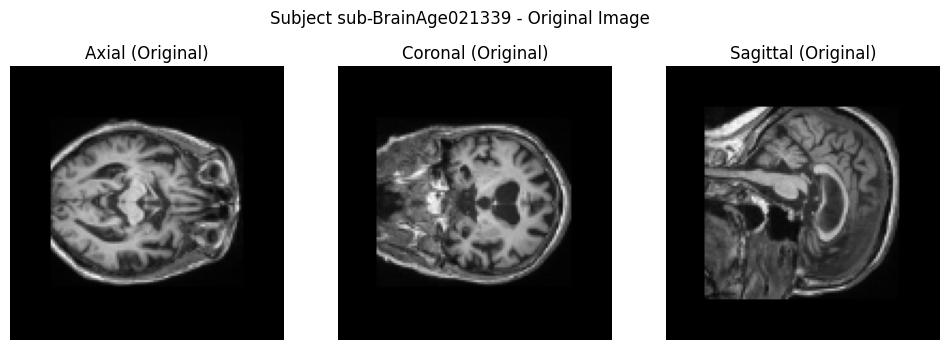

Target: Tuổi đích 25, Giới tính đích Nam


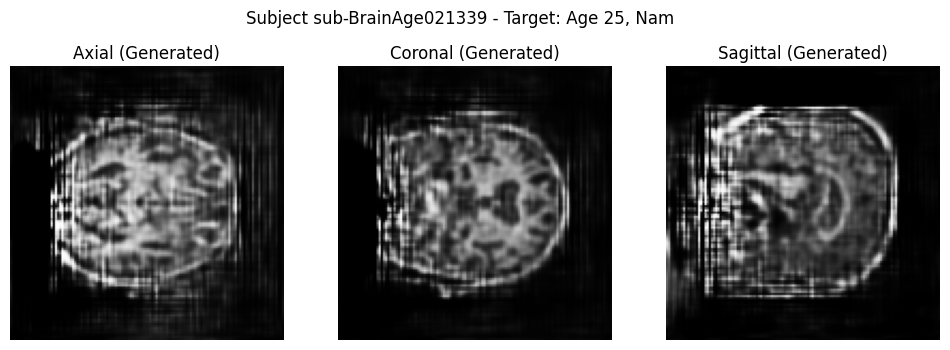

Target: Tuổi đích 25, Giới tính đích Nữ


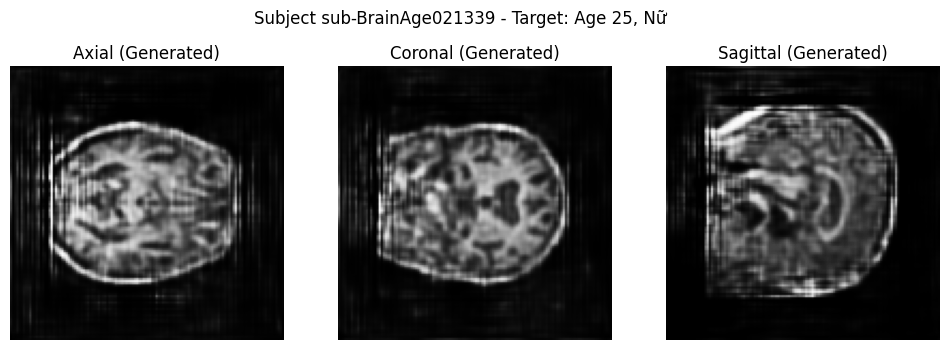

Target: Tuổi đích 50, Giới tính đích Nam


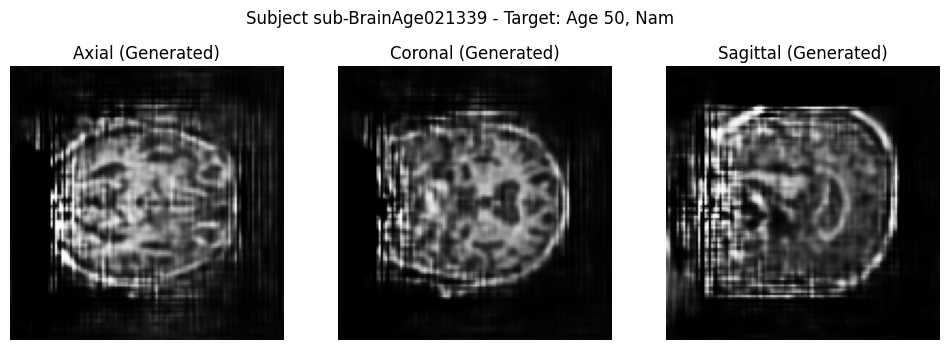

Target: Tuổi đích 50, Giới tính đích Nữ


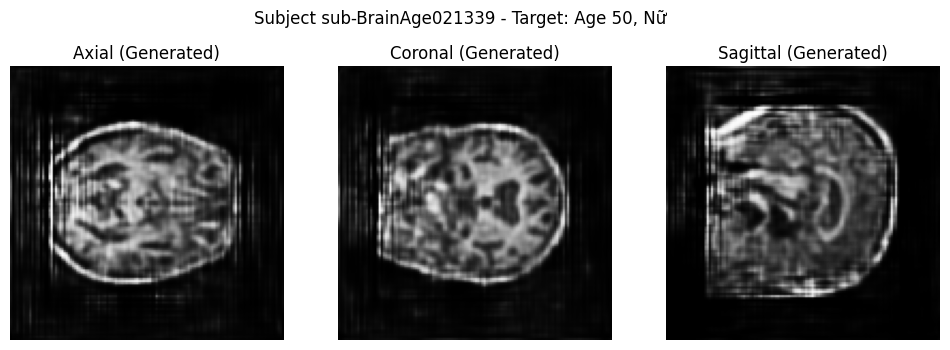


Hoàn thành kiểm tra. Ảnh đánh giá được lưu tại: /kaggle/working/evaluation


In [18]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib
import glob

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Giải phóng VRAM
torch.cuda.empty_cache()
# Tải dữ liệu
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
preprocessed_dir = "/kaggle/working/processed_mri_slices"

# Đọc thông tin subject từ participants.xlsx
participants_df = pd.read_excel(participants_file)
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Lấy danh sách subject
all_subjects = [d for d in os.listdir(preprocessed_dir) if os.path.isdir(os.path.join(preprocessed_dir, d)) and d.startswith('sub-BrainAge')]
print(f"Tổng số subject: {len(all_subjects)}")

# Chuẩn hóa tuổi
max_age = 97
min_age = 18  # Giả định, điều chỉnh sau khi chạy check_age_range.py

# Hàm tải và xử lý ảnh
def load_and_process_image(subject_id, preprocessed_dir):
    anat_dir = os.path.join(preprocessed_dir, subject_id, "anat")
    axial_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_axial.nii.gz")).get_fdata()[0]  # Shape: (128, 128)
    coronal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_coronal.nii.gz")).get_fdata()[0]
    sagittal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_sagittal.nii.gz")).get_fdata()[0]
    
    combined_slice = np.stack([axial_slice, coronal_slice, sagittal_slice], axis=0)  # Shape: (3, 128, 128)
    combined_tensor = torch.tensor(combined_slice, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 3, 128, 128)
    
    age = subject_info[subject_id]['age'] / max_age
    gender = subject_info[subject_id]['gender']
    condition = torch.tensor([age, gender], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 2)
    
    return combined_slice, combined_tensor, condition, age * max_age, gender

# Tải mô hình
G_A_to_B = Generator().to(device)
G_A_to_B.eval()

# Tìm file mô hình mới nhất
model_files = glob.glob("/kaggle/working/G_A_to_B_epoch_135.pth")
if not model_files:
    raise FileNotFoundError("Không tìm thấy file mô hình nào trong /kaggle/working/")
model_path = max(model_files, key=os.path.getctime)  # Lấy file mới nhất
print(f"Tải mô hình từ: {model_path}")
G_A_to_B.load_state_dict(torch.load(model_path))

# Tạo thư mục lưu ảnh đánh giá
eval_dir = "/kaggle/working/evaluation"
os.makedirs(eval_dir, exist_ok=True)

# Chọn ngẫu nhiên 3 subject để kiểm tra
test_subjects = random.sample(all_subjects, 3)

# Các giá trị tuổi và giới tính mục tiêu
target_conditions = [
    (25, 1),  # Tuổi 25, nam
    (25, 0),  # Tuổi 25, nữ
    (50, 1),  # Tuổi 50, nam
    (50, 0),  # Tuổi 50, nữ
]

# Kiểm tra từng subject
for subject_id in test_subjects:
    # Tải ảnh và thông tin gốc
    real_A_np, real_A_tensor, condition_A, orig_age, orig_gender = load_and_process_image(subject_id, preprocessed_dir)
    real_A_np = (real_A_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1] để hiển thị
    
    # Hiển thị và lưu ảnh gốc
    print(f"\nSubject: {subject_id}")
    print(f"Tuổi gốc: {orig_age:.1f}, Giới tính gốc: {'Nam' if orig_gender == 1 else 'Nữ'}")
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
        axes[i].imshow(real_A_np[i], cmap='gray')
        axes[i].set_title(f"{plane} (Original)")
        axes[i].axis('off')
    plt.suptitle(f"Subject {subject_id} - Original Image")
    plt.savefig(os.path.join(eval_dir, f"subject_{subject_id}_original.png"))
    plt.show()
    plt.close()
    
    # Kiểm tra với từng điều kiện mục tiêu
    for target_age, target_gender in target_conditions:
        if target_age < min_age or target_age > max_age:
            print(f"Bỏ qua target_age {target_age} vì ngoài phạm vi [{min_age}, {max_age}]")
            continue
        target_age_normalized = target_age / max_age
        condition_A_to_B = torch.tensor([
            condition_A[0, 0].item(),  # Tuổi gốc
            condition_A[0, 1].item(),  # Giới tính gốc
            target_age_normalized,     # Tuổi đích
            target_gender              # Giới tính đích
        ], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 4)
        
        # Sinh ảnh giả
        with torch.no_grad():
            fake_B = G_A_to_B(real_A_tensor, condition_A_to_B)  # Shape: (1, 3, 128, 128)
        
        # Chuyển tensor thành numpy để hiển thị
        fake_B_np = fake_B.squeeze(0).cpu().numpy()  # Shape: (3, 128, 128)
        fake_B_np = (fake_B_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1]
        
        # Hiển thị và lưu ảnh sinh ra
        print(f"Target: Tuổi đích {target_age}, Giới tính đích {'Nam' if target_gender == 1 else 'Nữ'}")
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
            axes[i].imshow(fake_B_np[i], cmap='gray')
            axes[i].set_title(f"{plane} (Generated)")
            axes[i].axis('off')
        plt.suptitle(f"Subject {subject_id} - Target: Age {target_age}, {'Nam' if target_gender == 1 else 'Nữ'}")
        plt.savefig(os.path.join(eval_dir, f"subject_{subject_id}_target_age_{target_age}_gender_{'male' if target_gender == 1 else 'female'}.png"))
        plt.show()
        plt.close()

print("\nHoàn thành kiểm tra. Ảnh đánh giá được lưu tại:", eval_dir)

In [ ]:
import os
import glob
import shutil
import json
from kaggle.api.kaggle_api_extended import KaggleApi

# Kiểm tra và sao chép kaggle.json
kaggle_json_path = '/kaggle/input/kaggle-json/kaggle.json'
if not os.path.exists(kaggle_json_path):
    raise FileNotFoundError(f"Không tìm thấy {kaggle_json_path}. Vui lòng tải file lên /kaggle/input/kaggle-json/")
else:
    print(f"Tìm thấy {kaggle_json_path}")

# Sao chép kaggle.json đến thư mục mặc định
os.makedirs('/root/.config/kaggle', exist_ok=True)
shutil.copy(kaggle_json_path, '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("Đã sao chép kaggle.json đến /root/.config/kaggle/")

# Thiết lập Kaggle API
api = KaggleApi()
try:
    api.authenticate()
    print("Xác thực Kaggle API thành công")
except Exception as e:
    raise Exception(f"Lỗi xác thực Kaggle API: {e}. Kiểm tra username/key trong kaggle.json")

# Thư mục chứa các file mô hình
working_dir = '/kaggle/working/'
model_files = glob.glob(os.path.join(working_dir, '*.pth'))

if not model_files:
    print("Không tìm thấy file .pth nào trong /kaggle/working/")
else:
    print(f"Tìm thấy {len(model_files)} file .pth")

    # Tạo thư mục tạm để chuẩn bị dataset
    temp_dataset_dir = '/tmp/kaggle_dataset'
    os.makedirs(temp_dataset_dir, exist_ok=True)

    # Sao chép các file .pth vào thư mục tạm
    for model_file in model_files:
        shutil.copy(model_file, temp_dataset_dir)

    # Tạo file metadata (dataset-metadata.json)
    dataset_metadata = {
        "title": "BrainAge_Models",
        "id": f"hongbitunanh/brainage-models",
        "licenses": [{"name": "CC0-1.0"}]
    }
    metadata_path = os.path.join(temp_dataset_dir, 'dataset-metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(dataset_metadata, f, indent=4)

    # Tải dataset lên Kaggle
    try:
        print("Đang tải dataset lên Kaggle...")
        api.dataset_create_new(temp_dataset_dir)
        print("Dataset đã được tải lên thành công! Kiểm tra tại: https://www.kaggle.com/datasets/hongbitunanh/brainage-models")
    except Exception as e:
        print(f"Lỗi khi tạo dataset mới: {e}")
        print("Thử cập nhật dataset hiện có...")
        try:
            api.dataset_create_version(temp_dataset_dir, version_notes="Cập nhật mô hình mới")
            print("Dataset đã được cập nhật thành công!")
        except Exception as e:
            print(f"Lỗi khi cập nhật dataset: {e}")

    # Dọn dẹp thư mục tạm
    shutil.rmtree(temp_dataset_dir)

In [ ]:
# Vẽ kết quả mẫu
real_A, condition_A = dataset[0]
real_A = real_A.unsqueeze(0).to(device)
condition_A = condition_A.unsqueeze(0).to(device)
target_age = torch.tensor([50.0 / max_age], dtype=torch.float32, device=device)
target_gender = torch.tensor([1.0], dtype=torch.float32, device=device)
condition_A_to_B = torch.tensor([condition_A[0, 0], condition_A[0, 1], target_age, target_gender], dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    fake_B = G_A_to_B(real_A, condition_A_to_B)
fake_B = fake_B.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Generated Axial")
plt.imshow(fake_B[0], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Generated Coronal")
plt.imshow(fake_B[1], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Generated Sagittal")
plt.imshow(fake_B[2], cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/generated_slices.png')
plt.close()

In [ ]:
# Vẽ kết quả mẫu
real_A, condition_A = dataset[0]
real_A = real_A.unsqueeze(0).to(device)
condition_A = condition_A.unsqueeze(0).to(device)
target_age = torch.tensor([50.0 / max_age], dtype=torch.float32, device=device)
target_gender = torch.tensor([1.0], dtype=torch.float32, device=device)
condition_A_to_B = torch.tensor([condition_A[0, 0], condition_A[0, 1], target_age, target_gender], dtype=torch.float32, device=device).unsqueeze(0)
with torch.no_grad():
    fake_B = G_A_to_B(real_A, condition_A_to_B)
fake_B = fake_B.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Generated Axial")
plt.imshow(fake_B[0], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title("Generated Coronal")
plt.imshow(fake_B[1], cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title("Generated Sagittal")
plt.imshow(fake_B[2], cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/generated_slices.png')
plt.show()
plt.close()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
import nibabel as nib

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Định nghĩa Generator (khớp với mô hình CycleGAN đã huấn luyện)
class Generator(nn.Module):
    def __init__(self, condition_dim=4):
        super(Generator, self).__init__()
        self.condition_dim = condition_dim
        self.condition_layer = nn.Sequential(
            nn.Linear(condition_dim, 64),
            nn.ReLU(),
        )
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 64, kernel_size=4, stride=2, padding=1),  # Input: 3 kênh ảnh + 1 kênh condition
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # Output: 3 kênh (axial, coronal, sagittal)
            nn.Tanh(),
        )
    
    def forward(self, x, condition):
        batch_size = x.size(0)
        condition = condition[:batch_size]
        condition = self.condition_layer(condition)
        condition = condition.view(batch_size, 1, 64, 1).expand(batch_size, 1, 64, 64)
        x = torch.cat([x, condition], dim=1)  # Shape: (batch_size, 4, 64, 64)
        x = self.encoder(x)
        x = self.decoder(x)  # Shape: (batch_size, 3, 64, 64)
        return x

# Tải dữ liệu
participants_file = "/kaggle/working/processed_mri_slices/participants.xlsx"
preprocessed_dir = "/kaggle/working/processed_mri_slices"

# Đọc thông tin subject từ participants.xlsx
participants_df = pd.read_excel(participants_file)
subject_info = {}
for _, row in participants_df.iterrows():
    subject_id = row['subject_id']
    subject_info[subject_id] = {
        'age': float(row['subject_age']),
        'gender': 1 if row['subject_sex'] == 'm' else 0
    }

# Lấy danh sách subject
all_subjects = [d for d in os.listdir(preprocessed_dir) if os.path.isdir(os.path.join(preprocessed_dir, d)) and d.startswith('sub-BrainAge')]
print(f"Tổng số subject: {len(all_subjects)}")

# Chuẩn hóa tuổi
max_age = 100

# Hàm tải và xử lý ảnh
def load_and_process_image(subject_id, preprocessed_dir):
    anat_dir = os.path.join(preprocessed_dir, subject_id, "anat")
    axial_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_axial.nii.gz")).get_fdata()[0]  # Shape: (64, 64)
    coronal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_coronal.nii.gz")).get_fdata()[0]
    sagittal_slice = nib.load(os.path.join(anat_dir, f"{subject_id}_T1w_sagittal.nii.gz")).get_fdata()[0]
    
    combined_slice = np.stack([axial_slice, coronal_slice, sagittal_slice], axis=0)  # Shape: (3, 64, 64)
    combined_tensor = torch.tensor(combined_slice, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 3, 64, 64)
    
    age = subject_info[subject_id]['age'] / max_age
    gender = subject_info[subject_id]['gender']
    condition = torch.tensor([age, gender], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 2)
    
    return combined_slice, combined_tensor, condition, age * max_age, gender

# Tải mô hình
G_A_to_B = Generator().to(device)
G_A_to_B.eval()

model_path = "/kaggle/working/G_A_to_B_epoch_399_batch_0.pth"  # Điều chỉnh epoch/batch nếu cần
print(f"Tải mô hình từ: {model_path}")
if os.path.exists(model_path):
    G_A_to_B.load_state_dict(torch.load(model_path))
else:
    raise FileNotFoundError(f"Không tìm thấy file mô hình tại {model_path}")

# Chọn ngẫu nhiên 3 subject để kiểm tra
test_subjects = random.sample(all_subjects, 3)

# Các giá trị tuổi và giới tính mục tiêu để kiểm tra
target_conditions = [
    (25, 1),  # Tuổi 25, nam
    (25, 0),  # Tuổi 60, nữ
    (50,1),
    (50,0)
]

# Kiểm tra từng subject
for subject_id in test_subjects:
    # Tải ảnh và thông tin gốc
    real_A_np, real_A_tensor, condition_A, orig_age, orig_gender = load_and_process_image(subject_id, preprocessed_dir)
    real_A_np = (real_A_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1] để hiển thị
    
    # Hiển thị ảnh gốc
    print(f"\nSubject: {subject_id}")
    print(f"Tuổi gốc: {orig_age:.1f}, Giới tính gốc: {'Nam' if orig_gender == 1 else 'Nữ'}")
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
        axes[i].imshow(real_A_np[i], cmap='gray')
        axes[i].set_title(f"{plane} (Original)")
        axes[i].axis('off')
    plt.suptitle(f"Subject {subject_id} - Original Image")
    plt.show()
    
    # Kiểm tra với từng điều kiện mục tiêu
    for target_age, target_gender in target_conditions:
        target_age_normalized = target_age / max_age
        condition_A_to_B = torch.tensor([
            condition_A[0, 0].item(),  # Tuổi gốc
            condition_A[0, 1].item(),  # Giới tính gốc
            target_age_normalized,     # Tuổi đích
            target_gender              # Giới tính đích
        ], dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 4)
        
        # Sinh ảnh giả
        with torch.no_grad():
            fake_B = G_A_to_B(real_A_tensor, condition_A_to_B)  # Shape: (1, 3, 64, 64)
        
        # Chuyển tensor thành numpy để hiển thị
        fake_B_np = fake_B.squeeze(0).cpu().numpy()  # Shape: (3, 64, 64)
        fake_B_np = (fake_B_np + 1) / 2  # Chuyển từ [-1, 1] về [0, 1]
        
        # Hiển thị ảnh sinh ra
        print(f"Target: Tuổi đích {target_age}, Giới tính đích {'Nam' if target_gender == 1 else 'Nữ'}")
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        for i, plane in enumerate(['Axial', 'Coronal', 'Sagittal']):
            axes[i].imshow(fake_B_np[i], cmap='gray')
            axes[i].set_title(f"{plane} (Generated)")
            axes[i].axis('off')
        plt.suptitle(f"Subject {subject_id} - Target: Age {target_age}, {'Nam' if target_gender == 1 else 'Nữ'}")
        plt.show()

print("\nHoàn thành kiểm tra.")


In [ ]:
import os
import shutil
import nibabel as nib
import numpy as np
import pandas as pd

# Đường dẫn
data_dir = "/kaggle/working/data_processed"
output_base_dir = "/kaggle/working/processed_mri_slices_128"
participants_file = os.path.join(data_dir, "participants.xlsx")

# Hàm tiền xử lý ảnh 2D
def preprocess_mri_slice(mri_slice):
    # Intensity normalization về [0, 1]
    mri_normalized = (mri_slice - mri_slice.min()) / (mri_slice.max() - mri_slice.min() + 1e-8)  # Tránh chia cho 0
    return mri_normalized

# Tạo danh sách file
file_list = []
for subject_id in os.listdir(data_dir):
    if subject_id.startswith('sub-BrainAge'):
        subject_dir = os.path.join(data_dir, subject_id, "anat")
        file_path = os.path.join(subject_dir, f"{subject_id}_T1w_processed.nii.gz")
        if os.path.exists(file_path):
            file_list.append(file_path)

# Kiểm tra file_list
if not file_list:
    raise ValueError("Không tìm thấy file nào khớp với mẫu *_T1w_processed.nii.gz trong thư mục data_processed!")

# Tạo thư mục đầu ra
os.makedirs(output_base_dir, exist_ok=True)
shutil.copy(participants_file, os.path.join(output_base_dir, "participants.xlsx"))

# Xử lý và lưu 3 mặt cắt 128x128
for idx, file_path in enumerate(file_list):
    subject_id = os.path.basename(os.path.dirname(os.path.dirname(file_path)))
    subject_output_dir = os.path.join(output_base_dir, subject_id, "anat")
    os.makedirs(subject_output_dir, exist_ok=True)
    
    # Đọc ảnh 3D
    mri_img = nib.load(file_path)
    mri_data = mri_img.get_fdata()  # Shape: (130, 130, 130)
    
    # Kiểm tra shape
    if mri_data.shape != (130, 130, 130):
        print(f"Cảnh báo: File {file_path} có shape {mri_data.shape}, không phải (130, 130, 130)")
        continue
    
    # Lấy 3 mặt cắt giữa
    axial_idx = mri_data.shape[2] // 2
    coronal_idx = mri_data.shape[1] // 2
    sagittal_idx = mri_data.shape[0] // 2
    
    axial_slice = mri_data[:, :, axial_idx]  # Shape: (130, 130)
    coronal_slice = mri_data[:, coronal_idx, :]  # Shape: (130, 130)
    sagittal_slice = mri_data[sagittal_idx, :, :]  # Shape: (130, 130)
    
    # Cắt 1 pixel mỗi chiều
    axial_slice = axial_slice[1:-1, 1:-1]  # Shape: (128, 128)
    coronal_slice = coronal_slice[1:-1, 1:-1]
    sagittal_slice = sagittal_slice[1:-1, 1:-1]
    
    # Tiền xử lý
    axial_normalized = preprocess_mri_slice(axial_slice)
    coronal_normalized = preprocess_mri_slice(coronal_slice)
    sagittal_normalized = preprocess_mri_slice(sagittal_slice)
    
    # Chuẩn hóa về [-1, 1]
    axial_final = axial_normalized * 2 - 1
    coronal_final = coronal_normalized * 2 - 1
    sagittal_final = sagittal_normalized * 2 - 1
    
    # Lưu 3 mặt cắt
    for slice_type, slice_data in [
        ('axial', axial_final),
        ('coronal', coronal_final),
        ('sagittal', sagittal_final)
    ]:
        output_file = os.path.join(subject_output_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
        slice_data_3d = slice_data[np.newaxis, :, :]  # Shape: (1, 128, 128)
        nib.save(nib.Nifti1Image(slice_data_3d, np.eye(4)), output_file)
    

print(f"Đã lưu tất cả dữ liệu 128x128 vào: {output_base_dir}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import nibabel as nib
import pandas as pd
import time
import matplotlib.pyplot as plt

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

# Dataset cho super-resolution
class SRDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, subjects, target_shape_lr=(64, 64), target_shape_hr=(128, 128)):
        self.lr_dir = lr_dir  # Thư mục ảnh 64x64
        self.hr_dir = hr_dir  # Thư mục ảnh 128x128
        self.subjects = subjects
        self.target_shape_lr = target_shape_lr
        self.target_shape_hr = target_shape_hr
    
    def __len__(self):
        return len(self.subjects)
    
    def __getitem__(self, idx):
        subject_id = self.subjects[idx]
        lr_subject_dir = os.path.join(self.lr_dir, subject_id, "anat")
        hr_subject_dir = os.path.join(self.hr_dir, subject_id, "anat")
        
        # Đọc 3 mặt cắt 64x64 (low-resolution)
        lr_slices = []
        for slice_type in ['axial', 'coronal', 'sagittal']:
            file_path = os.path.join(lr_subject_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
            mri_img = nib.load(file_path)
            mri_data = mri_img.get_fdata()[0]  # Shape: (64, 64)
            lr_slices.append(mri_data)
        lr_tensor = torch.tensor(np.stack(lr_slices), dtype=torch.float32)  # Shape: (3, 64, 64)
        
        # Đọc 3 mặt cắt 128x128 (high-resolution)
        hr_slices = []
        for slice_type in ['axial', 'coronal', 'sagittal']:
            file_path = os.path.join(hr_subject_dir, f"{subject_id}_T1w_{slice_type}.nii.gz")
            mri_img = nib.load(file_path)
            mri_data = mri_img.get_fdata()[0]  # Shape: (128, 128)
            hr_slices.append(mri_data)
        hr_tensor = torch.tensor(np.stack(hr_slices), dtype=torch.float32)  # Shape: (3, 128, 128)
        
        return lr_tensor, hr_tensor

# Mô hình SRResNet
class SRResNet(nn.Module):
    def __init__(self, num_residual_blocks=8):
        super(SRResNet, self).__init__()
        
        # Initial convolution
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, stride=1, padding=4),
            nn.PReLU(),
        )
        
        # Residual blocks
        self.res_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(64),
                nn.PReLU(),
                nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(64),
            ) for _ in range(num_residual_blocks)
        ])
        
        # Post-residual convolution
        self.post_res = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
        )
        
        # Upsampling (64x64 -> 128x128)
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1),
            nn.PixelShuffle(upscale_factor=2),  # 64x64 -> 128x128
            nn.PReLU(),
        )
        
        # Final convolution
        self.final = nn.Conv2d(64, 3, kernel_size=9, stride=1, padding=4)
    
    def forward(self, x):
        # Initial feature extraction
        x = self.initial(x)
        
        # Residual blocks
        residual = x
        for res_block in self.res_blocks:
            x = res_block(x) + x  # Skip connection
        x = self.post_res(x) + residual
        
        # Upsampling
        x = self.upsample(x)
        
        # Final output
        x = self.final(x)
        return torch.tanh(x)  # Đầu ra [-1, 1]

# Tạo danh sách subjects
lr_dir = "/kaggle/working/processed_mri_slices"
hr_dir = "/kaggle/working/processed_mri_slices_128"
subjects = [s for s in os.listdir(lr_dir) if s.startswith('sub-BrainAge')]

# Tạo Dataset và DataLoader
dataset = SRDataset(lr_dir, hr_dir, subjects)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

# Khởi tạo mô hình
model = SRResNet().to(device)

# Loss function và optimizer
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.999))

# Mixed precision
scaler = torch.amp.GradScaler('cuda')

# Huấn luyện
epochs = 100
for epoch in range(epochs):
    losses = []
    num_batches = 0
    data_time = 0
    model_time = 0
    
    for i, (lr_images, hr_images) in enumerate(dataloader):
        start_time = time.time()
        lr_images = lr_images.to(device)  # Shape: (batch_size, 3, 64, 64)
        hr_images = hr_images.to(device)  # Shape: (batch_size, 3, 128, 128)
        data_time += time.time() - start_time
        
        optimizer.zero_grad()
        
        model_start = time.time()
        with torch.amp.autocast('cuda'):
            sr_images = model(lr_images)  # Shape: (batch_size, 3, 128, 128)
            loss = criterion(sr_images, hr_images)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        model_time += time.time() - model_start
        
        losses.append(loss.item())
        num_batches += 1
        
        if i % 100 == 0:
            torch.save(model.state_dict(), f"/kaggle/working/sr_model_epoch_{epoch}_batch_{i}.pth")
            print(f"Batch {i}, Data time: {data_time:.2f}s, Model time: {model_time:.2f}s, VRAM: {torch.cuda.memory_allocated() / 1024**2:.2f}MB, Loss: {loss.item():.4f}")
    
    avg_loss = sum(losses) / num_batches if num_batches > 0 else 0
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

# Vẽ kết quả mẫu
lr_images, hr_images = dataset[0]
lr_images = lr_images.unsqueeze(0).to(device)
hr_images = hr_images.unsqueeze(0).to(device)
with torch.no_grad():
    sr_images = model(lr_images)
sr_images = sr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
hr_images = hr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
lr_images = lr_images.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 15))
for j, title in enumerate(["Axial", "Coronal", "Sagittal"]):
    # Low-resolution
    plt.subplot(3, 3, j+1)
    plt.title(f"LR {title} (64x64)")
    plt.imshow(lr_images[j], cmap='gray')
    plt.axis('off')
    # Super-resolution
    plt.subplot(3, 3, j+4)
    plt.title(f"SR {title} (128x128)")
    plt.imshow(sr_images[j], cmap='gray')
    plt.axis('off')
    # High-resolution
    plt.subplot(3, 3, j+7)
    plt.title(f"HR {title} (128x128)")
    plt.imshow(hr_images[j], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sr_sample.png')
plt.show()
plt.close()

In [ ]:
# Vẽ kết quả mẫu
lr_images, hr_images = dataset[0]
lr_images = lr_images.unsqueeze(0).to(device)
hr_images = hr_images.unsqueeze(0).to(device)
with torch.no_grad():
    sr_images = model(lr_images)
sr_images = sr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
hr_images = hr_images.cpu().numpy()[0]  # Shape: (3, 128, 128)
lr_images = lr_images.cpu().numpy()[0]  # Shape: (3, 64, 64)

plt.figure(figsize=(15, 15))
for j, title in enumerate(["Axial", "Coronal", "Sagittal"]):
    # Low-resolution
    plt.subplot(3, 3, j+1)
    plt.title(f"LR {title} (64x64)")
    plt.imshow(lr_images[j], cmap='gray')
    plt.axis('off')
    # Super-resolution
    plt.subplot(3, 3, j+4)
    plt.title(f"SR {title} (128x128)")
    plt.imshow(sr_images[j], cmap='gray')
    plt.axis('off')
    # High-resolution
    plt.subplot(3, 3, j+7)
    plt.title(f"HR {title} (128x128)")
    plt.imshow(hr_images[j], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/sr_sample.png')
plt.show()
plt.close()